Exploratory Analysis

Working notebook used to understand the PLACES data before writing the scripts

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("../data/raw/places_county_2025.csv", thousands=",")
print(raw.shape)
raw.head()

(3143, 167)


,StateAbbr,StateDesc,CountyName,CountyFIPS,TotalPopulation,TotalPop18plus,ACCESS2_CrudePrev,ACCESS2_Crude95CI,ACCESS2_AdjPrev,ACCESS2_Adj95CI,...,SHUTUTILITY_Adj95CI,LACKTRPT_CrudePrev,LACKTRPT_Crude95CI,LACKTRPT_AdjPrev,LACKTRPT_Adj95CI,EMOTIONSPT_CrudePrev,EMOTIONSPT_Crude95CI,EMOTIONSPT_AdjPrev,EMOTIONSPT_Adj95CI,Geolocation
0,KY,Kentucky,Trigg,21221,14369,11280,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-87.8732998555619 36.8063370344073)
1,KY,Kentucky,Wayne,21231,19580,15608,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-84.8283531236799 36.8008845409014)
2,KY,Kentucky,Washington,21229,12267,9420,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-85.175051728938 37.7532982899311)
3,PA,Pennsylvania,Perry,42099,46083,36495,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-77.2622712474235 40.3984083146619)
4,PA,Pennsylvania,Venango,42121,49431,39983,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-79.7581868804174 41.4006288227586)


In [13]:
adj = [c for c in raw.columns if c.endswith("_AdjPrev")]
missing = raw[adj].isna().sum().sort_values(ascending=False)
print(missing.head(15).to_string())

FOODSTAMP_AdjPrev      844
HOUSINSECU_AdjPrev     844
SHUTUTILITY_AdjPrev    844
EMOTIONSPT_AdjPrev     844
LONELINESS_AdjPrev     844
FOODINSECU_AdjPrev     844
LACKTRPT_AdjPrev       844
ACCESS2_AdjPrev        187
CHD_AdjPrev            187
CASTHMA_AdjPrev        187
CANCER_AdjPrev         187
BPMED_AdjPrev          187
BPHIGH_AdjPrev         187
BINGE_AdjPrev          187
ARTHRITIS_AdjPrev      187


In [14]:
none_at_all = raw[raw["ACCESS2_AdjPrev"].isna()]
print(len(none_at_all))
print(none_at_all["StateDesc"].value_counts().head(10))

187
StateDesc
Kentucky        120
Pennsylvania     67
Name: count, dtype: int64


In [15]:
df = pd.read_csv("../data/processed/county_features.csv")
print(df.shape)
df[["uninsured", "diabetes", "poor_health",
    "access_barrier_score", "disease_burden_score"]].describe().round(2)

(2299, 25)


,uninsured,diabetes,poor_health,access_barrier_score,disease_burden_score
count,2299.00,2299.00,2299.00,2299.00,2299.00
mean,10.56,11.12,20.45,0.00,-0.00
std,3.13,2.26,4.44,0.73,0.91
min,4.00,6.70,10.40,-1.64,-2.38
25%,8.40,9.50,17.10,-0.50,-0.61
50%,9.90,10.60,19.70,-0.18,-0.13
75%,12.10,12.40,23.30,0.37,0.54
max,26.70,21.30,39.70,3.72,4.01


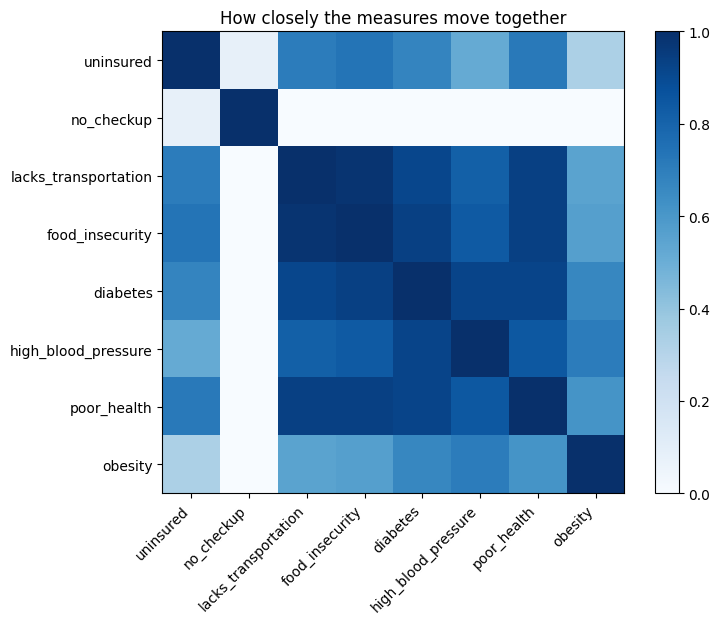

In [16]:
cols = ["uninsured", "no_checkup", "lacks_transportation", "food_insecurity",
        "diabetes", "high_blood_pressure", "poor_health", "obesity"]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols)
fig.colorbar(im)
ax.set_title("How closely the measures move together")
plt.show()